In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from collections import namedtuple

from scipy.signal import find_peaks

## Model

Model has many parameters. To keep them in order,
we can use namedtuple or dictionary. Here, we use
namedtuple

In [27]:
# Create a named tuple with its fields (attributes) —- our parameters -- listed in the second input argument
# Values are assigned to each parameter later in the code
params = namedtuple('params', ['C',
                               'g_L', 'g_Na', 'g_K', 'g_M',
                               'E_L', 'E_Na', 'E_K', 'E_M',
                               'V_half_m', 'V_half_n', 'V_half_n_M',
                               'k_m', 'k_n', 'k_M',
                               'tau', 'tau_M',
                               'Istim_func'
                              ])

params.__doc__

'params(C, g_L, g_Na, g_K, g_M, E_L, E_Na, E_K, E_M, V_half_m, V_half_n, V_half_n_M, k_m, k_n, k_M, tau, tau_M, Istim_func)'

In [28]:
def model(t, state, model_parameters):

    """ Reduced HH model - Eqs. 2.20-2.25 of the lecture notes.

    Parameters
    ----------

        - t : scalar
            Time point at which to evaluate
            dv/dt and dn/dt.

        - state : tuple with 2 elements
            Values of `v` and `n` at which to evaluate
            dv/dt and dn/dt.

        - model_parameters : collections.namedtuple
            Values of model parameters are attributes
            of `model_parameters`.

    Returns
    -------

        - tuple with 2 elements
            dv/dt and dn/dt

    """

    C = model_parameters.C
    g_L = model_parameters.g_L
    g_Na = model_parameters.g_Na
    g_K = model_parameters.g_K
    g_M = model_parameters.g_M
    E_L = model_parameters.E_L
    E_Na = model_parameters.E_Na
    E_K = model_parameters.E_K
    E_M = model_parameters.E_M
    V_half_m = model_parameters.V_half_m
    V_half_n = model_parameters.V_half_n
    V_half_n_M = model_parameters.V_half_n_M
    k_m = model_parameters.k_m
    k_n = model_parameters.k_n
    k_M = model_parameters.k_M
    tau = model_parameters.tau
    tau_M = model_parameters.tau_M
    Istim_func = model_parameters.Istim_func # Callable. Must receive t as an argument and return stim current

    v = state[0]
    n = state[1]
    n_M = state[2]

    m_inf = 1 / (1 + np.exp((V_half_m - v) / k_m) )
    n_inf = 1 / (1 + np.exp((V_half_n - v) / k_n) )
    n_inf_M = 1 / (1 + np.exp((V_half_n_M - v) / k_M) )

    I_leak = g_L*(v - E_L)
    I_na = g_Na*m_inf*(v - E_Na)
    I_k = g_K*n*(v - E_K)
    I_M = g_M*n_M*(v - E_M)

    dvdt = (Istim_func(t) - I_leak - I_na - I_k - I_M) / C
    dndt = (n_inf - n) / tau
    dn_Mdt = (n_inf_M - n_M) / tau_M

    return (dvdt, dndt, dn_Mdt)

## Parameters

In [29]:
# Parameters as in Table 2.4 of the lecture notes

I = 5

BaseParams = params(
C = 1,
g_L = 8,
E_L = -80,
g_Na = 20,
E_Na = 60,
g_M = 5,
E_M = -90,
g_K = 9,
E_K = -90,
V_half_m = -20,
k_m = 15,
tau = 0.152,
tau_M = 20,
V_half_n = -25,
V_half_n_M = -20,
k_n = 5,
k_M = 5,
Istim_func = lambda t_val : I # Constant stimulating current
)

In [30]:
BaseParams.g_M

5

In [31]:
# Set time limits, time-step, t_start
t_span = [0, 400]

dt = 0.01 # sec

t_start = 0

t_eval = np.arange(t_start, t_span[1], dt)

## Task 4 Intrinsic bursting. g_M = 5 (Fig 1.6)

In [32]:
state_initial = (-60, 0.2, 0.02)
solution = solve_ivp(model, t_span, state_initial, args=[BaseParams,], t_eval=t_eval)

### Figure

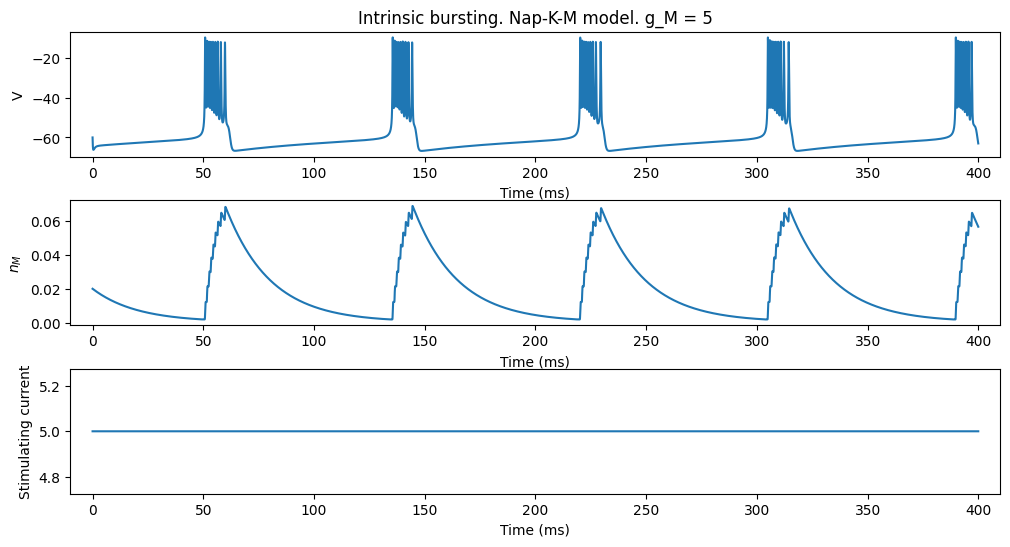

In [33]:
f, axs = plt.subplots(3, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title(f'Intrinsic bursting. Nap-K-M model. g_M = {BaseParams.g_M}')

axs[1].plot(solution.t, solution.y[2])
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('$n_M$')

axs[2].plot(t_eval, [BaseParams.Istim_func(ti) for ti in t_eval])
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)

## Task 4 No Intrinsic bursting. g_M = 0

In [34]:
BaseParams.g_M

5

In [35]:
state_initial = (-60, 0.2, 0.02)

p = BaseParams._replace(g_M = 0)

solution = solve_ivp(model, t_span, state_initial, args=[p,], t_eval=t_eval)

### Figure

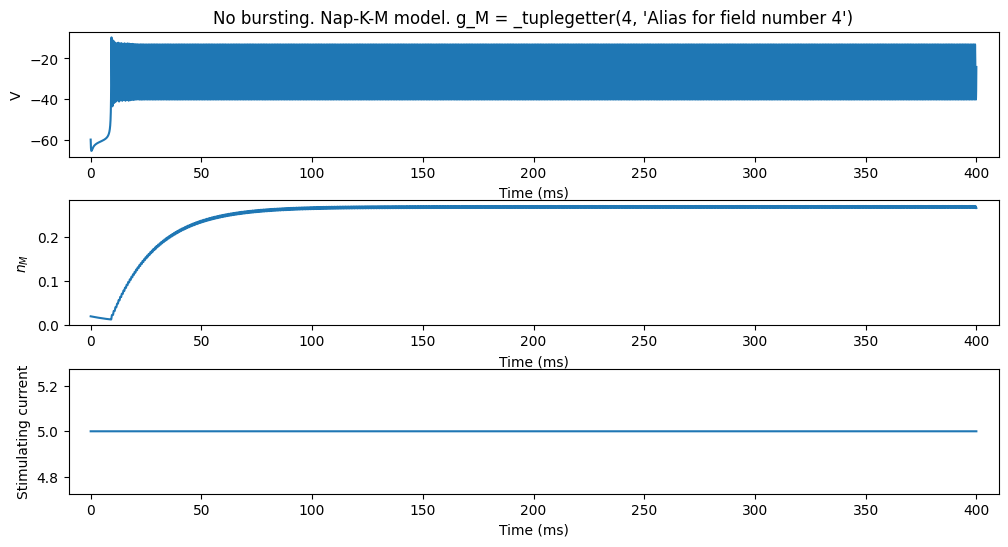

In [36]:
f, axs = plt.subplots(3, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title(f'No bursting. Nap-K-M model. g_M = {params.g_M}')

axs[1].plot(solution.t, solution.y[2])
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('$n_M$')

axs[2].plot(t_eval, [BaseParams.Istim_func(ti) for ti in t_eval])
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)

## Task 4 Intrinsic bursting. g_M = 5 Try different $\tau_M$

#### $\tau_M = 5$

In [37]:
p = BaseParams._replace(tau_M = 5)

solution = solve_ivp(model, t_span, state_initial, args=[p,], t_eval=t_eval)

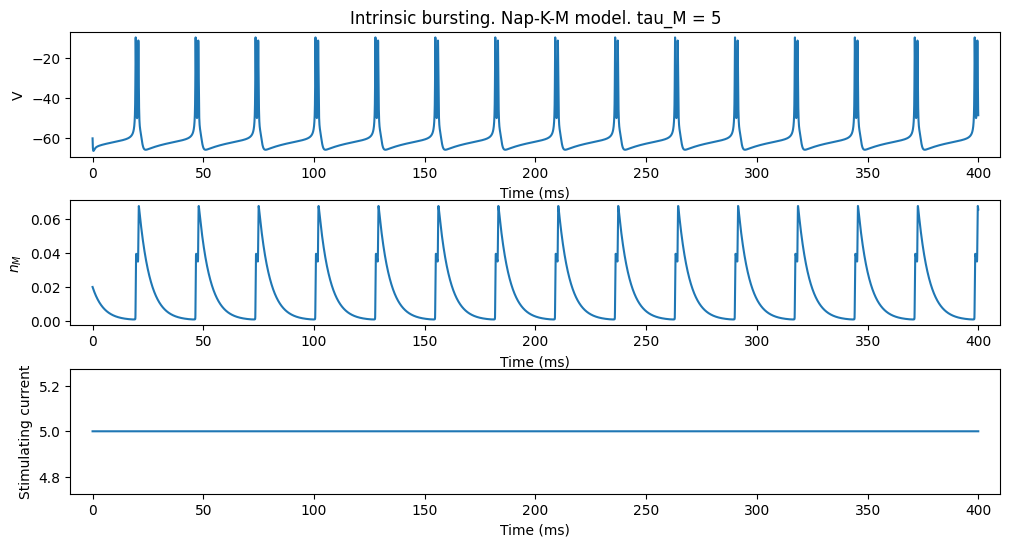

In [38]:
f, axs = plt.subplots(3, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title(f'Intrinsic bursting. Nap-K-M model. tau_M = {p.tau_M}')

axs[1].plot(solution.t, solution.y[2])
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('$n_M$')

axs[2].plot(t_eval, [BaseParams.Istim_func(ti) for ti in t_eval])
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)

Text(0, 0.5, '$V$')

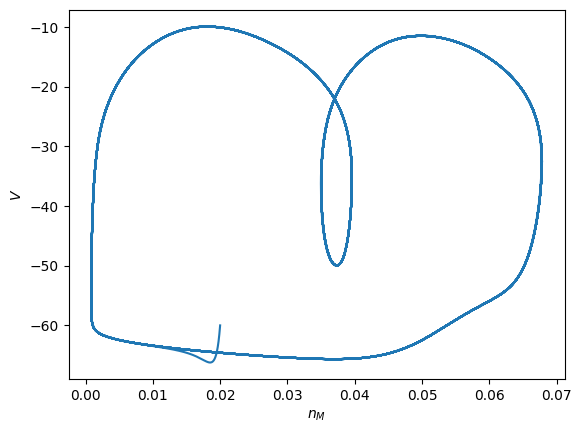

In [39]:
plt.plot(solution.y[2], solution.y[0])
plt.xlabel('$n_M$')
plt.ylabel('$V$')

#### $\tau_M = 10$

In [40]:

p = BaseParams._replace(tau_M = 10)
solution = solve_ivp(model, t_span, state_initial, args=[p,], t_eval=t_eval)

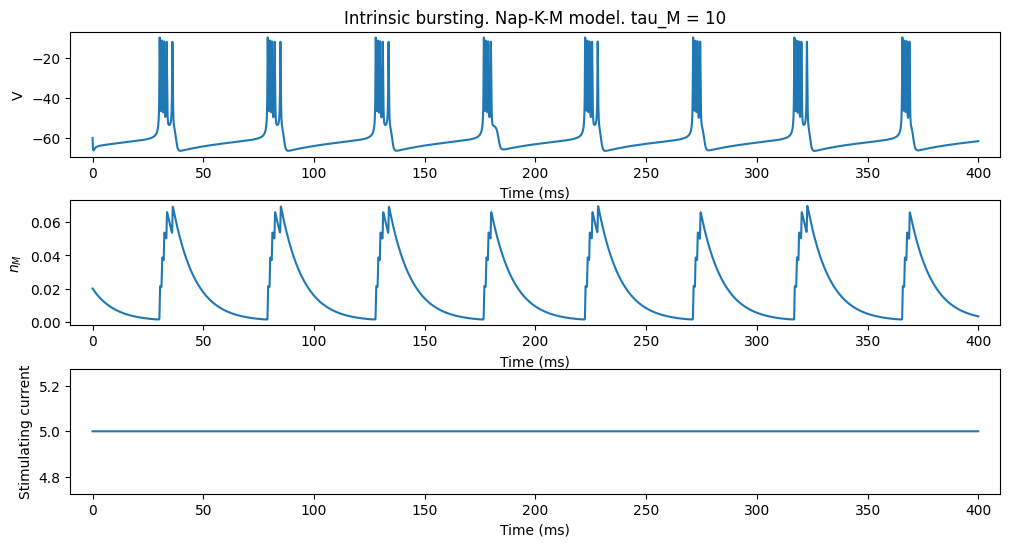

In [41]:
f, axs = plt.subplots(3, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title(f'Intrinsic bursting. Nap-K-M model. tau_M = {p.tau_M}')

axs[1].plot(solution.t, solution.y[2])
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('$n_M$')

axs[2].plot(t_eval, [BaseParams.Istim_func(ti) for ti in t_eval])
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)

Text(0, 0.5, '$V$')

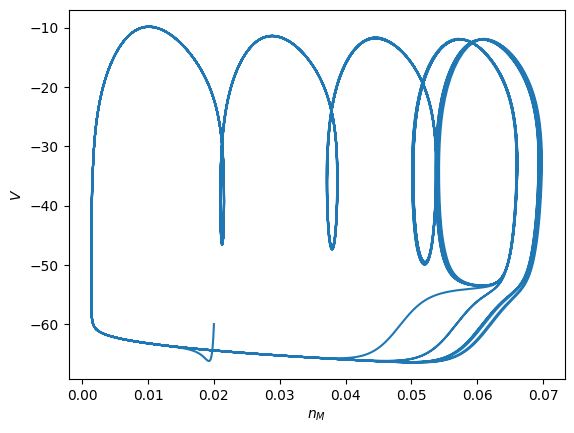

In [42]:
plt.plot(solution.y[2], solution.y[0])
plt.xlabel('$n_M$')
plt.ylabel('$V$')

#### $\tau_M = 25$

In [43]:

p = BaseParams._replace(tau_M = 25)
solution = solve_ivp(model, t_span, state_initial, args=[p,], t_eval=t_eval)

/tmp/ipython-input-1489268284.py:51: RuntimeWarning: overflow encountered in exp
  m_inf = 1 / (1 + np.exp((V_half_m - v) / k_m) )
/tmp/ipython-input-1489268284.py:52: RuntimeWarning: overflow encountered in exp
  n_inf = 1 / (1 + np.exp((V_half_n - v) / k_n) )
/tmp/ipython-input-1489268284.py:53: RuntimeWarning: overflow encountered in exp
  n_inf_M = 1 / (1 + np.exp((V_half_n_M - v) / k_M) )


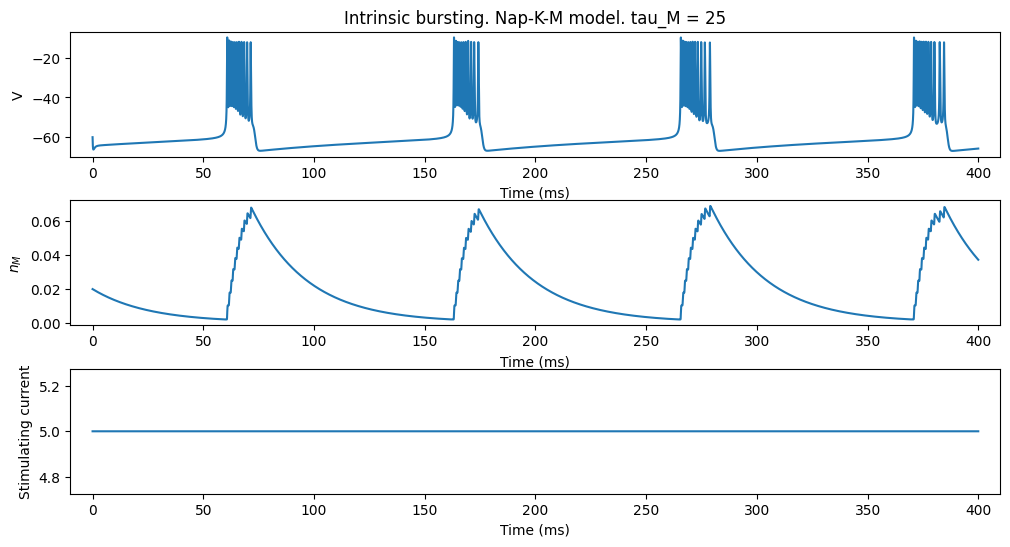

In [44]:
f, axs = plt.subplots(3, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title(f'Intrinsic bursting. Nap-K-M model. tau_M = {p.tau_M}')

axs[1].plot(solution.t, solution.y[2])
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('$n_M$')

axs[2].plot(t_eval, [BaseParams.Istim_func(ti) for ti in t_eval])
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)

Text(0, 0.5, '$V$')

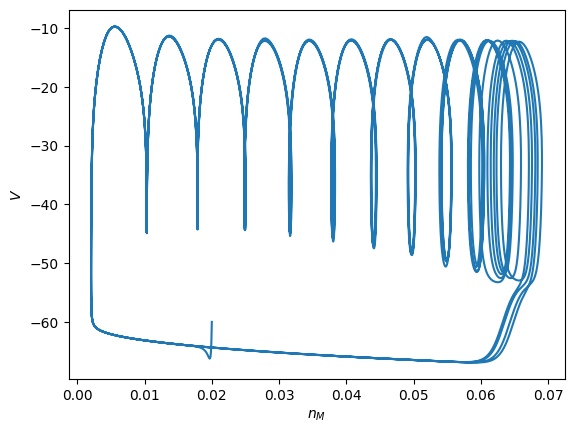

In [45]:
plt.plot(solution.y[2], solution.y[0])
plt.xlabel('$n_M$')
plt.ylabel('$V$')